# Ximenez: Parse (New)

# Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import sys
sys.path.append("../../local_lib/")
from narrative_parser import NarrativeParser

In [2]:
src_id = "ximenez"

# Source to LINE

In [3]:
xml_lines = open("xom-all-flat-mod-pnums.xml").readlines()

els = dict(
    lang = "",
    folio = 0,
    side = 0,
    para_num = 0,
    lb = 0,
)

data = []

for line in xml_lines:
    if re.match(r"<div xml:lang", line):
        els["lang"] = line.split('"')[1].split('"')[0]
        els["para_num"] = 0
    if re.match(r"^<pb ", line):
        f, s = line.split("xom-")[1].split('"')[0].split("-")
        els["folio"] = int(f[1:])
        els["side"] = int(s[1:])
        els["lb"] = 0
    if re.match(r"^<p ", line):
        els["para_num"] += 1
    if re.match(r"^<lb n=", line):
        els["lb"] += 1
        els["lb_str"] = " ".join(line.split("/>")[1:]).strip()
        data.append(tuple(els.values()))

LINE = pd.DataFrame(data, columns=list(els.keys()))
LINE = LINE.set_index(["lang", "folio", "side", "para_num", "lb"])
assert LINE.index.has_duplicates == False, "LINE has duplicates"

**Clean line strings**

In [4]:
LINE["lb_str_plain"] = LINE.lb_str.str.replace(r"<[^>]+/?>", "", regex=True).str.replace(" –", "–", regex=False)
chars = {"Ꜩ": "Tz", "ꜩ": "tz", "ꜫ": "q'", "ÿ": "i"}
for char in chars:
    LINE.lb_str_plain = LINE.lb_str_plain.str.replace(char, chars[char], regex=False)

# LINE to DOC

In [5]:
LINE_QUC = LINE.loc["quc"]
DOC = (
    LINE_QUC
    .groupby(["para_num"]).lb_str_plain
    .apply(lambda x: " ".join(map(str, x)))
    .to_frame("doc_str")
)
DOC.doc_str = DOC.doc_str.str.replace(r"– ", "").str.strip()
DOC

,doc_str
para_num,
1,ARE V XE OHER Tzih varal Quiche vbi.
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...
3,"ARE V TzIHOXIC VAE Cacatzinin oc, caca chamam ..."
4,Vae cute nabe tzih nabe vchan. mahabi oq' hun ...
5,Ta xpe cut vtzih varal xul cuq ri tepeu gucuma...
...,...
93,Arecut nim ha ri chuvach nihaibab are vbinaam ...
94,Are chicut rech ahau qui che va vmam vcahau Ma...
95,Arecut ahauab ri chuvach ahau quiche are vleel...


# Parse

In [6]:
parser = NarrativeParser(src_id, DOC)
parser.run()

# Inspect

In [7]:
parser.VOCAB

,n,p,i,h,dh
term_str,,,,,
a,53,0.002044,8.934136,0.018265,4.901988
ab,1,0.000039,14.662056,0.000566,0.000000
abah,24,0.000926,10.077094,0.009329,3.907268
abanel,1,0.000039,14.662056,0.000566,0.000000
abanoh,1,0.000039,14.662056,0.000566,0.000000
...,...,...,...,...,...
zui,1,0.000039,14.662056,0.000566,0.000000
zul,1,0.000039,14.662056,0.000566,0.000000
zutz,1,0.000039,14.662056,0.000566,0.000000


In [8]:
parser.CHUNK.head()

,chunk_str,doc_id
chunk_num,,
0,are v xe oher tzih varal quiche vbi varal xchi...,1 2 3 4 5
1,qazlem hupacha ta cha uaxoc ta caquiro puch ap...,5 6 7
2,xeqhauic xeqha chic qui bil quib maui mixutzin...,7 8
3,camul alom camul qaholom nimac nima tziz ah cu...,8 9
4,vach rumal che abah xqhauic ronohel qui quebal...,9 10


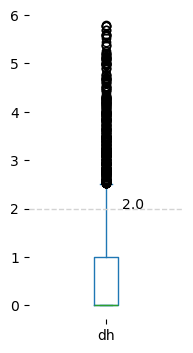

Vocab size: 5605  |  SIGs: 500


In [9]:
ax = parser.VOCAB.dh.plot.box(figsize=(2, 4))
vline = parser.VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls="--", lw=1, c="lightgray")
ax.annotate(vline, xy=(1.1, 2))
sns.despine(left=True, bottom=True)
plt.show()

print(f"Vocab size: {len(parser.VOCAB)}  |  SIGs: {len(parser.SIGS)}")

In [10]:
parser.TFIDF

term_str,vtzilah,quixoquil,huiub,recha,cuchumaquic,vholom,quetaam,ivech,cama,vpa,...,vi,cu,rumal,chic,qui,xa,ri,cut,chi,ta
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.159961,...,0.032995,0.010679,0.039700,0.025906,0.007304,0.047334,0.025785,0.016624,0.037052,0.033564
1,0.000000,0.000000,0.062899,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.072175,0.021562,0.010020,0.026154,0.011061,0.047788,0.046857,0.043636,0.021376,0.064691
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.041993,0.030579,0.037894,0.086547,0.017430,0.084715,0.017228,0.034909,0.010105,0.055337
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.043150,0.021118,0.067481,0.051448,0.025223,0.025296,0.028766,0.023215
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.032130,0.024956,0.092779,0.037840,0.068280,0.048397,0.021091,0.046620,0.043296,0.042785
5,0.000000,0.000000,0.264237,0.231435,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.069970,0.011323,0.052617,0.006867,0.030978,0.025094,0.068349,0.042303,0.039286,0.038823
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.182011,0.000000,...,0.037544,0.060754,0.101638,0.058955,0.024933,0.060592,0.073349,0.052963,0.036137,0.052078
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.032633,0.050695,0.023558,0.061493,0.030341,0.063200,0.058145,0.067081,0.056539,0.061563
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.014556,0.042399,0.013135,0.051430,0.053168,0.031323,0.064839,0.052803,0.035027,0.088843
